# 01 linear regression optimized
1. modélisation sur le dataset optimisÃƒÂ© sans data leakage.


In [1]:
"""
Linear Regression - dataset optimise sans data leakage.

Ce script charge les fichiers optimises, entraine une regression lineaire,
calcule les metriques et sauvegarde les resultats.
"""

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


MODEL_NAME = "Linear Regression"


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape


print("=" * 70)
print(f"MODELE : {MODEL_NAME}")
print("=" * 70)

start_load = time.time()
X_train = pd.read_csv("../data/processed/X_train_optimized.csv")
X_test = pd.read_csv("../data/processed/X_test_optimized.csv")
y_train = pd.read_csv("../data/processed/y_train_optimized.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_optimized.csv").values.ravel()
load_time = time.time() - start_load

print(f"Chargement termine en {load_time:.2f} secondes")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

print("\nDebut de l'entrainement...")
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Entrainement termine en {train_time:.2f} secondes")

print("\nPrediction sur le test...")
start_pred = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - start_pred

mae, rmse, r2, mape = evaluate_model(y_test, y_pred)

print("\n" + "=" * 70)
print("RESULTATS")
print("=" * 70)
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f} euros")
print(f"RMSE : {rmse:,.2f} euros")
print(f"MAPE : {mape:.2f} %")
print(f"Temps entrainement : {train_time:.2f} secondes")
print(f"Temps prediction   : {pred_time:.2f} secondes")

result = pd.DataFrame([{
    "model": MODEL_NAME,
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "train_time_sec": train_time,
    "pred_time_sec": pred_time
}])

result.to_csv("result_linear_regression_optimized.csv", index=False)
print("\nResultat sauvegarde : result_linear_regression_optimized.csv")




MODELE : Linear Regression
Chargement termine en 8.50 secondes
X_train : (3712577, 13)
X_test  : (928145, 13)
y_train : (3712577,)
y_test  : (928145,)

Debut de l'entrainement...
Entrainement termine en 4.80 secondes

Prediction sur le test...

RESULTATS
R2   : 0.4521
MAE  : 93,975.09 euros
RMSE : 185,066.85 euros
MAPE : 52.59 %
Temps entrainement : 4.80 secondes
Temps prediction   : 0.33 secondes

Resultat sauvegarde : result_linear_regression_optimized.csv


2. Analyse des features

In [2]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.named_steps["model"].coef_
})

feature_importance["abs_coef"] = feature_importance["coef"].abs()
feature_importance = feature_importance.sort_values("abs_coef", ascending=False)

print(feature_importance)

                      feature           coef       abs_coef
11            commune_prix_m2  157454.217497  157454.217497
0         surface_reelle_bati  144368.469100  144368.469100
8                   is_maison   43008.008161   43008.008161
1   nombre_pieces_principales  -31381.246341   31381.246341
2             surface_terrain  -23130.037045   23130.037045
7                    latitude  -17645.850434   17645.850434
5            code_departement  -12837.152428   12837.152428
9                     is_neuf   12305.461878   12305.461878
12             commune_volume    5272.053405    5272.053405
10            anciennete_mois   -3021.319192    3021.319192
3                       annee    2616.365897    2616.365897
6                   longitude   -1860.591821    1860.591821
4                        mois    1461.389468    1461.389468


3. Analyse de la loss

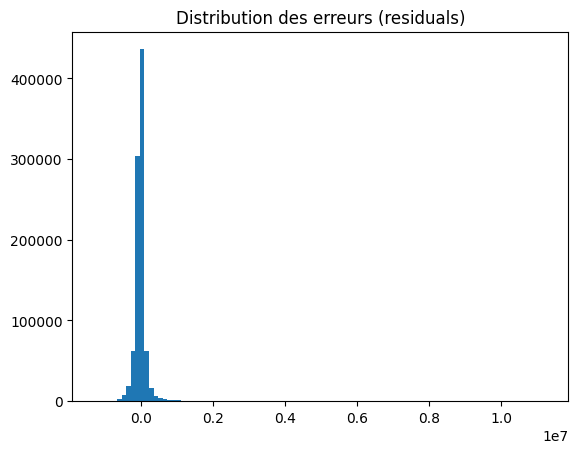

In [3]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=100)
plt.title("Distribution des erreurs (residuals)")
plt.show()

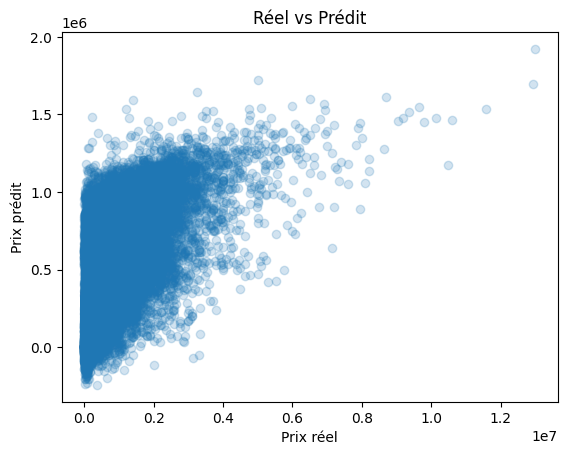

In [4]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.2)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Réel vs Prédit")
plt.show()

4. Shap

c:\Users\carine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
LinearExplainer explainer: 928146it [00:11, 10194.12it/s]                            


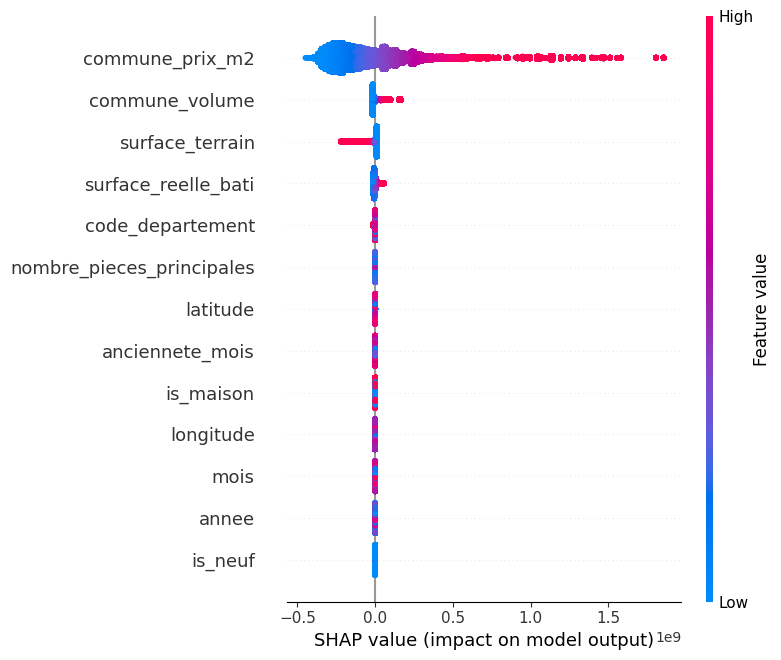

In [5]:
import shap

explainer = shap.Explainer(model.named_steps["model"], X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# 02 Régression Ridge optimized
1. modélisation sur le dataset optimisÃƒÂ© sans data leakage.

In [6]:
"""
Ridge Regression - dataset optimise sans data leakage.

Ridge est une baseline lineaire regularisee. Les variables sont standardisees
car le modele est sensible aux differences d'echelle.
"""

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


MODEL_NAME = "Ridge Regression"


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape


print("=" * 70)
print(f"MODELE : {MODEL_NAME}")
print("=" * 70)

start_load = time.time()
X_train = pd.read_csv("../data/processed/X_train_optimized.csv")
X_test = pd.read_csv("../data/processed/X_test_optimized.csv")
y_train = pd.read_csv("../data/processed/y_train_optimized.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_optimized.csv").values.ravel()
load_time = time.time() - start_load

print(f"Chargement termine en {load_time:.2f} secondes")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

print("\nDebut de l'entrainement...")
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Entrainement termine en {train_time:.2f} secondes")

start_pred = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - start_pred

mae, rmse, r2, mape = evaluate_model(y_test, y_pred)

print("\n" + "=" * 70)
print("RESULTATS")
print("=" * 70)
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f} euros")
print(f"RMSE : {rmse:,.2f} euros")
print(f"MAPE : {mape:.2f} %")

coef_df = pd.DataFrame({
    "variable": X_train.columns,
    "coefficient": model.named_steps["model"].coef_
})
coef_df["coefficient_abs"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("coefficient_abs", ascending=False)

print("\nTop variables selon les coefficients Ridge :")
print(coef_df.head(10))

pd.DataFrame([{
    "model": MODEL_NAME,
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "train_time_sec": train_time,
    "pred_time_sec": pred_time
}]).to_csv("result_ridge_regression_optimized.csv", index=False)

coef_df.to_csv("importance_ridge_regression_optimized.csv", index=False)
print("\nResultats sauvegardes.")




MODELE : Ridge Regression
Chargement termine en 8.41 secondes
X_train : (3712577, 13)
X_test  : (928145, 13)

Debut de l'entrainement...
Entrainement termine en 3.15 secondes

RESULTATS
R2   : 0.4521
MAE  : 93,975.07 euros
RMSE : 185,066.85 euros
MAPE : 52.59 %

Top variables selon les coefficients Ridge :
                     variable    coefficient  coefficient_abs
11            commune_prix_m2  157454.155939    157454.155939
0         surface_reelle_bati  144368.215303    144368.215303
8                   is_maison   43007.975510     43007.975510
1   nombre_pieces_principales  -31381.033483     31381.033483
2             surface_terrain  -23129.998201     23129.998201
7                    latitude  -17645.803141     17645.803141
5            code_departement  -12837.109539     12837.109539
9                     is_neuf   12305.454646     12305.454646
12             commune_volume    5272.060232      5272.060232
10            anciennete_mois   -3021.318259      3021.318259

Resultats

3. Analyse de la loss

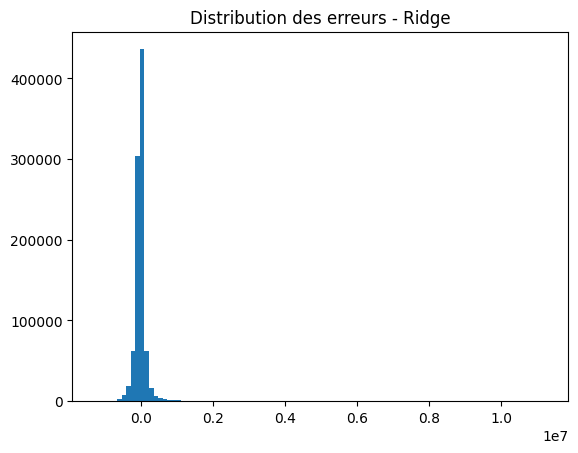

In [7]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=100)
plt.title("Distribution des erreurs - Ridge")
plt.show()

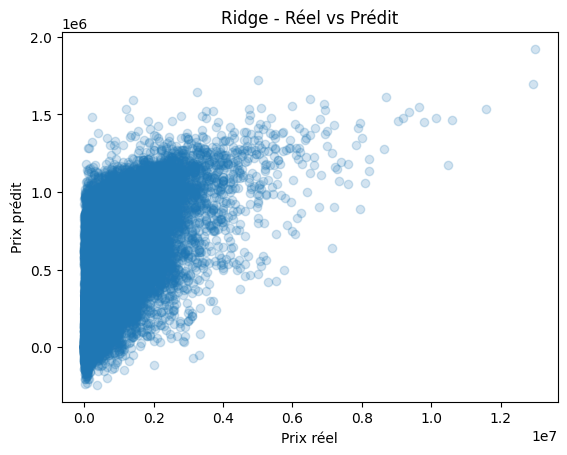

In [8]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.2)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Ridge - Réel vs Prédit")
plt.show()

3. Overfitting check

In [9]:
train_pred = model.predict(X_train)

print("R2 train :", r2_score(y_train, train_pred))
print("R2 test  :", r2_score(y_test, y_pred))

R2 train : 0.4520704736424863
R2 test  : 0.45212900438371295


4. Shap ( comparaison avec autres modèles)

LinearExplainer explainer: 928146it [00:11, 10071.06it/s]                            


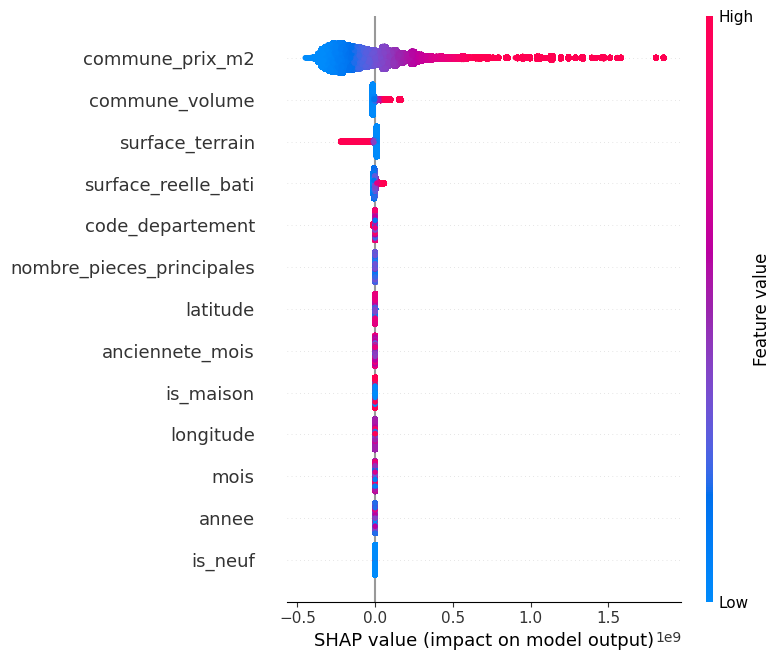

In [10]:
import shap

explainer = shap.Explainer(model.named_steps["model"], X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# 03 Random Forest optimized
1. modélisation sur le dataset optimisÃƒÂ© sans data leakage.

In [11]:
"""
Random Forest - dataset optimise sans data leakage.

Modele d'ensemble robuste base sur plusieurs arbres de decision.
"""

import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


MODEL_NAME = "Random Forest"


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape


print("=" * 70)
print(f"MODELE : {MODEL_NAME}")
print("=" * 70)

X_train = pd.read_csv("../data/processed/X_train_optimized.csv")
X_test = pd.read_csv("../data/processed/X_test_optimized.csv")
y_train = pd.read_csv("../data/processed/y_train_optimized.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_optimized.csv").values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=20,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nDebut de l'entrainement Random Forest...")
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Entrainement termine en {train_time / 60:.2f} minutes")

start_pred = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - start_pred

mae, rmse, r2, mape = evaluate_model(y_test, y_pred)

print("\n" + "=" * 70)
print("RESULTATS")
print("=" * 70)
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f} euros")
print(f"RMSE : {rmse:,.2f} euros")
print(f"MAPE : {mape:.2f} %")

importance_df = pd.DataFrame({
    "variable": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop variables Random Forest :")
print(importance_df.head(10))

pd.DataFrame([{
    "model": MODEL_NAME,
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "train_time_sec": train_time,
    "pred_time_sec": pred_time
}]).to_csv("result_random_forest_optimized.csv", index=False)

importance_df.to_csv("importance_random_forest_optimized.csv", index=False)
print("\nResultats sauvegardes.")




MODELE : Random Forest
X_train : (3712577, 13)
X_test  : (928145, 13)

Debut de l'entrainement Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 10.6min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 30.8min finished


Entrainement termine en 30.85 minutes


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    5.8s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   14.8s finished



RESULTATS
R2   : 0.7357
MAE  : 61,249.03 euros
RMSE : 128,548.07 euros
MAPE : 34.39 %

Top variables Random Forest :
                     variable  importance
0         surface_reelle_bati    0.451401
11            commune_prix_m2    0.441834
6                   longitude    0.023893
2             surface_terrain    0.022216
7                    latitude    0.017819
1   nombre_pieces_principales    0.011898
10            anciennete_mois    0.009508
12             commune_volume    0.009394
8                   is_maison    0.004205
5            code_departement    0.002949

Resultats sauvegardes.


2. Loss

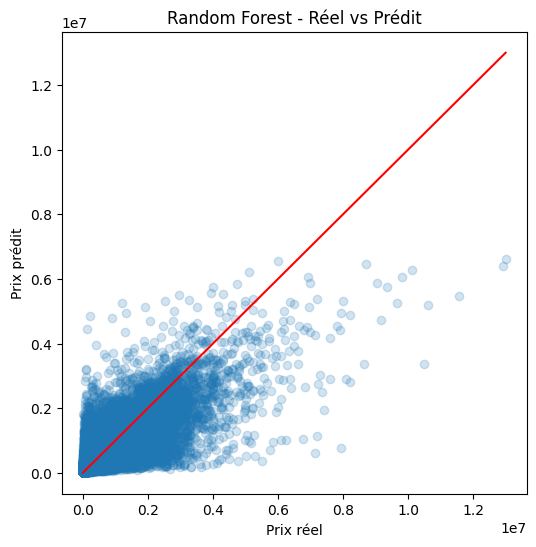

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2)

plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Random Forest - Réel vs Prédit")

# diagonale parfaite
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.show()

3. Features

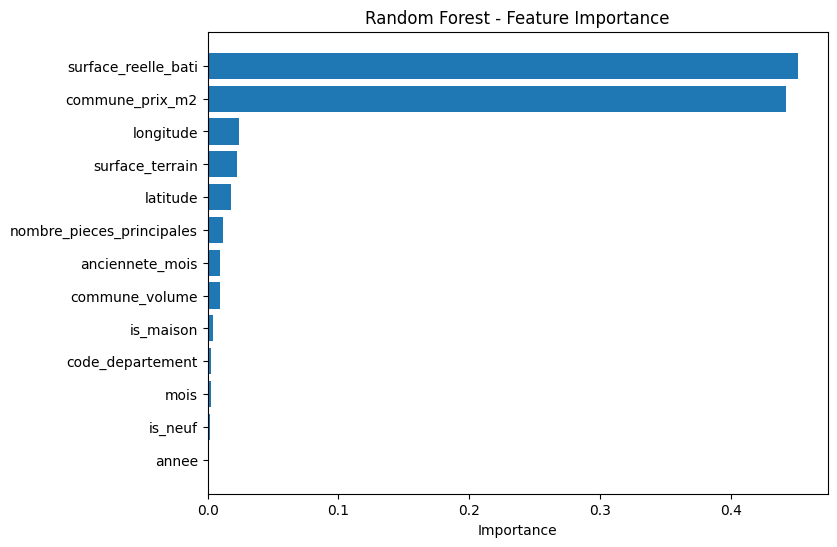

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feature_importance["feature"], feature_importance["importance"])

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.show()

4. Shap avec TreeExplainer

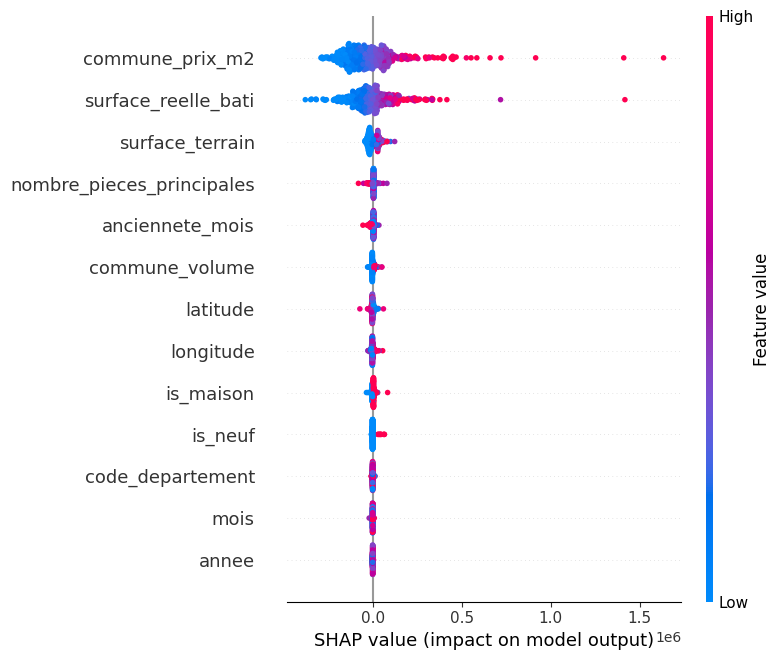

In [14]:
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
shap_values = explainer(X_sample)

shap.summary_plot(shap_values.values, X_sample)

# 04 Extratrees
1. modélisation sur le dataset optimisÃƒÂ© sans data leakage.

In [15]:
"""
ExtraTrees Regressor - dataset optimise sans data leakage.

Modele non lineaire proche du Random Forest, avec davantage d'aleatoire.
"""

import time
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


MODEL_NAME = "ExtraTrees"


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape


print("=" * 70)
print(f"MODELE : {MODEL_NAME}")
print("=" * 70)

X_train = pd.read_csv("../data/processed/X_train_optimized.csv")
X_test = pd.read_csv("../data/processed/X_test_optimized.csv")
y_train = pd.read_csv("../data/processed/y_train_optimized.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_optimized.csv").values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

model = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nDebut de l'entrainement ExtraTrees...")
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Entrainement termine en {train_time / 60:.2f} minutes")

start_pred = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - start_pred

mae, rmse, r2, mape = evaluate_model(y_test, y_pred)

print("\n" + "=" * 70)
print("RESULTATS")
print("=" * 70)
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f} euros")
print(f"RMSE : {rmse:,.2f} euros")
print(f"MAPE : {mape:.2f} %")

importance_df = pd.DataFrame({
    "variable": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop variables ExtraTrees :")
print(importance_df.head(10))

pd.DataFrame([{
    "model": MODEL_NAME,
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "train_time_sec": train_time,
    "pred_time_sec": pred_time
}]).to_csv("result_extratrees_optimized.csv", index=False)

importance_df.to_csv("importance_extratrees_optimized.csv", index=False)
print("\nResultats sauvegardes.")




MODELE : ExtraTrees
X_train : (3712577, 13)
X_test  : (928145, 13)

Debut de l'entrainement ExtraTrees...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 29.6min finished


Entrainement termine en 29.57 minutes


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    6.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   16.0s finished



RESULTATS
R2   : 0.7295
MAE  : 62,889.89 euros
RMSE : 130,043.25 euros
MAPE : 35.35 %

Top variables ExtraTrees :
                     variable  importance
11            commune_prix_m2    0.474386
0         surface_reelle_bati    0.344115
1   nombre_pieces_principales    0.077144
8                   is_maison    0.036768
2             surface_terrain    0.014833
12             commune_volume    0.013219
6                   longitude    0.010017
7                    latitude    0.008628
10            anciennete_mois    0.005296
5            code_departement    0.005034

Resultats sauvegardes.


2. Loss

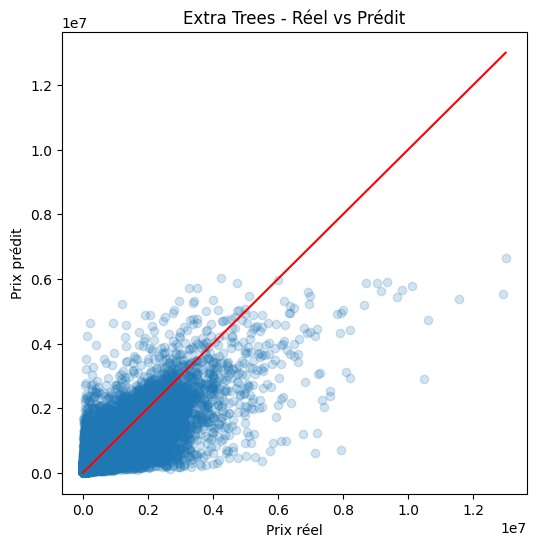

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2)

plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Extra Trees - Réel vs Prédit")

# diagonale parfaite
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.show()

3. FEATURES

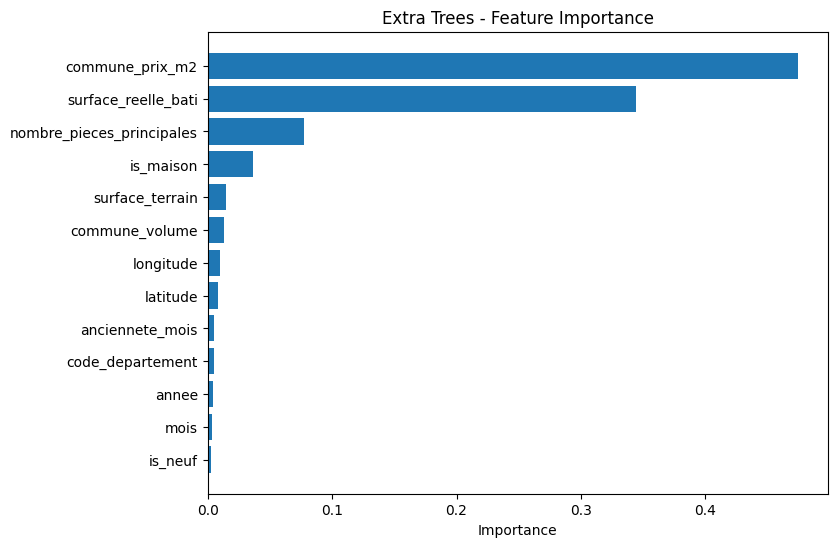

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feature_importance["feature"], feature_importance["importance"])

plt.title("Extra Trees - Feature Importance")
plt.xlabel("Importance")
plt.show()

4. SHAP

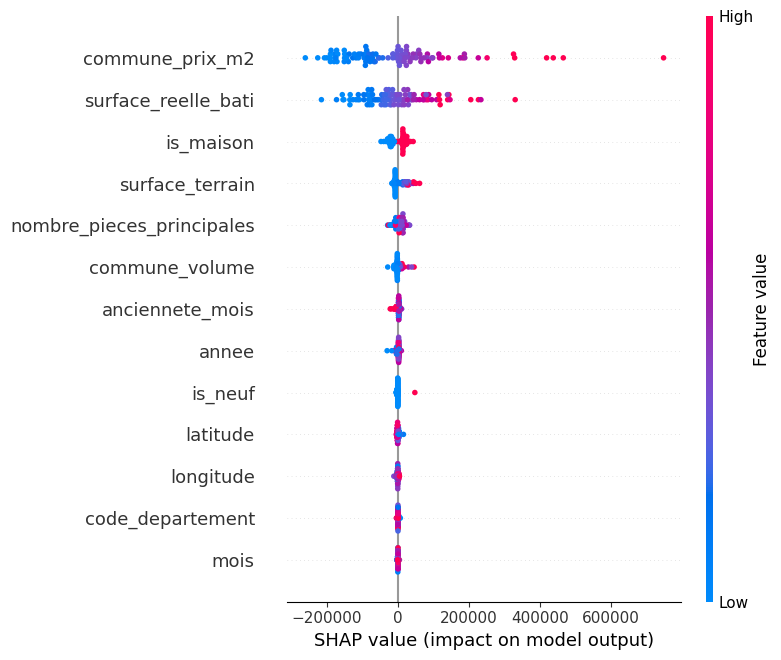

In [18]:
import shap

X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values.values, X_sample)

# 05 Lightgbm 
1. modélisation sur le dataset optimisÃƒÂ© sans data leakage.

In [19]:
"""
LightGBM - dataset optimise sans data leakage.

Modele de boosting rapide, adapte aux gros volumes de donnees tabulaires.
"""

import time
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


MODEL_NAME = "LightGBM"


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape


print("=" * 70)
print(f"MODELE : {MODEL_NAME}")
print("=" * 70)

try:
    import lightgbm as lgb
except ImportError as exc:
    raise ImportError(
        "LightGBM n'est pas installe. Installer avec : pip install lightgbm"
    ) from exc

X_train = pd.read_csv("../data/processed/X_train_optimized.csv")
X_test = pd.read_csv("../data/processed/X_test_optimized.csv")
y_train = pd.read_csv("../data/processed/y_train_optimized.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_optimized.csv").values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("\nDebut de l'entrainement LightGBM...")
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Entrainement termine en {train_time / 60:.2f} minutes")

start_pred = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - start_pred

mae, rmse, r2, mape = evaluate_model(y_test, y_pred)

print("\n" + "=" * 70)
print("RESULTATS")
print("=" * 70)
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f} euros")
print(f"RMSE : {rmse:,.2f} euros")
print(f"MAPE : {mape:.2f} %")

importance_df = pd.DataFrame({
    "variable": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop variables LightGBM :")
print(importance_df.head(10))

pd.DataFrame([{
    "model": MODEL_NAME,
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "train_time_sec": train_time,
    "pred_time_sec": pred_time
}]).to_csv("result_lightgbm_optimized.csv", index=False)

importance_df.to_csv("importance_lightgbm_optimized.csv", index=False)
print("\nResultats sauvegardes.")




MODELE : LightGBM
X_train : (3712577, 13)
X_test  : (928145, 13)

Debut de l'entrainement LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.267007 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1737
[LightGBM] [Info] Number of data points in the train set: 3712577, number of used features: 13
[LightGBM] [Info] Start training from score 244789.134750
Entrainement termine en 2.54 minutes

RESULTATS
R2   : 0.7467
MAE  : 61,408.26 euros
RMSE : 125,842.67 euros
MAPE : 34.71 %

Top variables LightGBM :
                     variable  importance
0         surface_reelle_bati       11841
11            commune_prix_m2        8315
7                    latitude        7206
6                   longitude        7055
2             surface_terrain        7005
12             commune_volume        5422
1   nombre_pieces_principales        5190
10            anciennete_mois        3956
5            code_dep

2. Loss

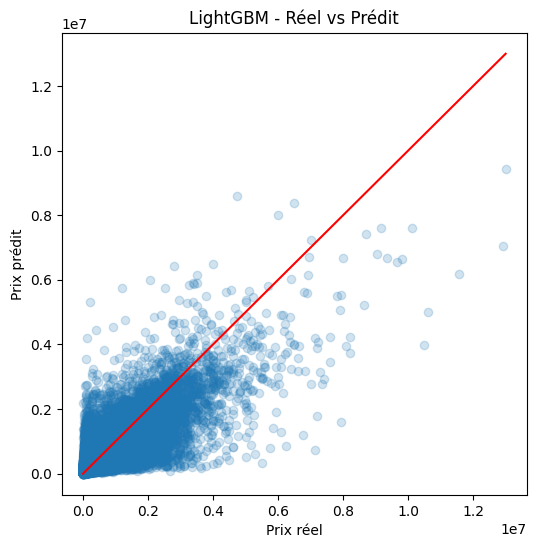

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2)

plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("LightGBM - Réel vs Prédit")

# diagonale parfaite
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.show()

3. FEATURES

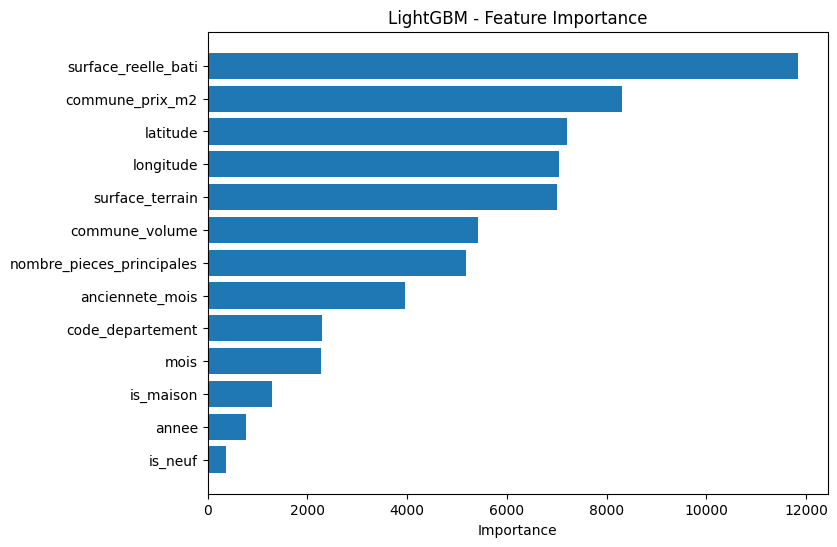

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feature_importance["feature"], feature_importance["importance"])

plt.title("LightGBM - Feature Importance")
plt.xlabel("Importance")
plt.show()

4. SHAP

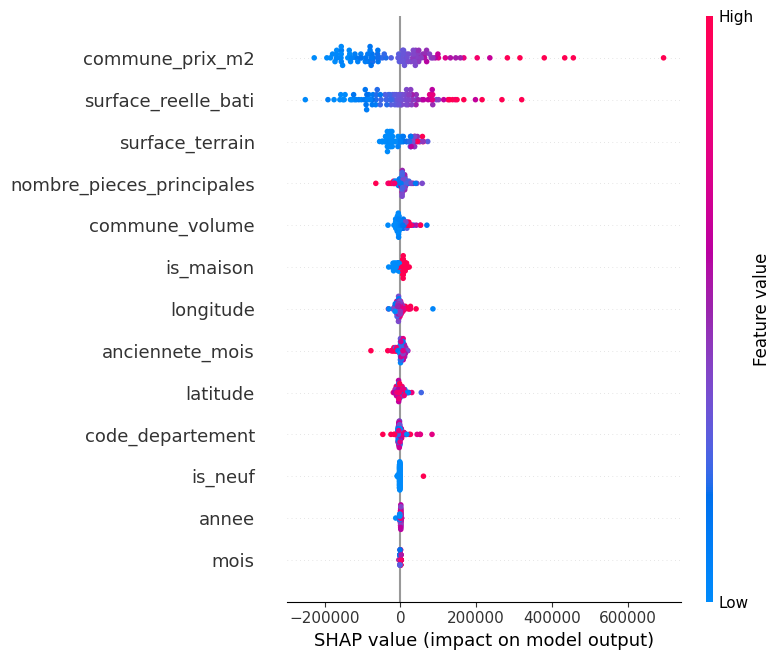

In [22]:
import shap

X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values.values, X_sample)

# 06 XGBoost
1. modélisation sur le dataset optimisÃƒÂ© sans data leakage.

In [23]:
"""
XGBoost - dataset optimise sans data leakage.

Modele de boosting performant pour donnees tabulaires complexes.
"""

import time
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


MODEL_NAME = "XGBoost"


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape


print("=" * 70)
print(f"MODELE : {MODEL_NAME}")
print("=" * 70)

try:
    import xgboost as xgb
except ImportError as exc:
    raise ImportError(
        "XGBoost n'est pas installe. Installer avec : pip install xgboost"
    ) from exc

X_train = pd.read_csv("../data/processed/X_train_optimized.csv")
X_test = pd.read_csv("../data/processed/X_test_optimized.csv")
y_train = pd.read_csv("../data/processed/y_train_optimized.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_optimized.csv").values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

print("\nDebut de l'entrainement XGBoost...")
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Entrainement termine en {train_time / 60:.2f} minutes")

start_pred = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - start_pred

mae, rmse, r2, mape = evaluate_model(y_test, y_pred)

print("\n" + "=" * 70)
print("RESULTATS")
print("=" * 70)
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f} euros")
print(f"RMSE : {rmse:,.2f} euros")
print(f"MAPE : {mape:.2f} %")

importance_df = pd.DataFrame({
    "variable": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop variables XGBoost :")
print(importance_df.head(10))

pd.DataFrame([{
    "model": MODEL_NAME,
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "train_time_sec": train_time,
    "pred_time_sec": pred_time
}]).to_csv("result_xgboost_optimized.csv", index=False)

importance_df.to_csv("importance_xgboost_optimized.csv", index=False)
print("\nResultats sauvegardes.")




MODELE : XGBoost
X_train : (3712577, 13)
X_test  : (928145, 13)

Debut de l'entrainement XGBoost...
Entrainement termine en 5.48 minutes

RESULTATS
R2   : 0.7463
MAE  : 60,738.99 euros
RMSE : 125,930.17 euros
MAPE : 34.20 %

Top variables XGBoost :
                     variable  importance
11            commune_prix_m2    0.352159
0         surface_reelle_bati    0.246611
5            code_departement    0.070314
1   nombre_pieces_principales    0.064803
8                   is_maison    0.044938
12             commune_volume    0.041053
9                     is_neuf    0.039590
6                   longitude    0.035462
7                    latitude    0.032234
2             surface_terrain    0.031800

Resultats sauvegardes.


2. Loss

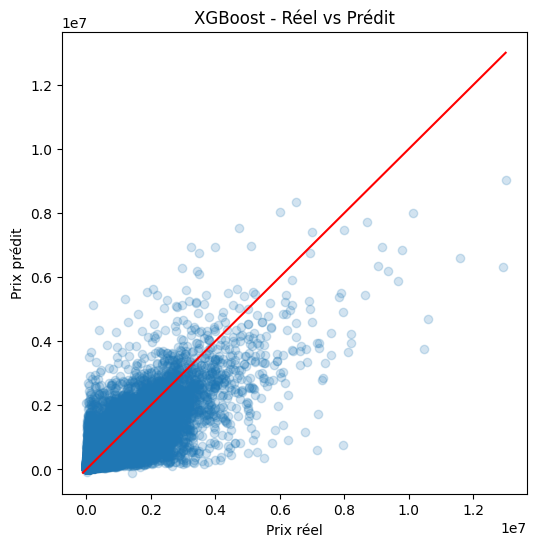

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2)

plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("XGBoost - Réel vs Prédit")

# diagonale parfaite
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.show()

3. FEATURES

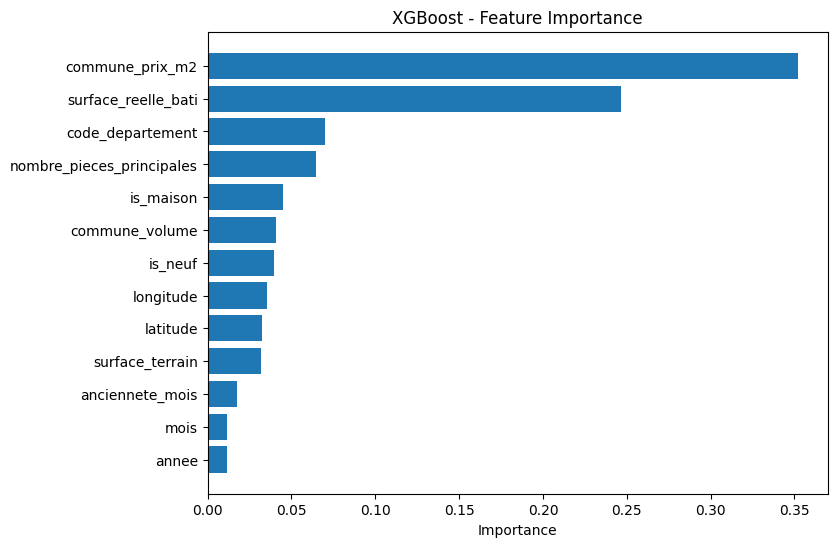

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feature_importance["feature"], feature_importance["importance"])

plt.title("XGBoost - Feature Importance")
plt.xlabel("Importance")
plt.show()

4. Shap

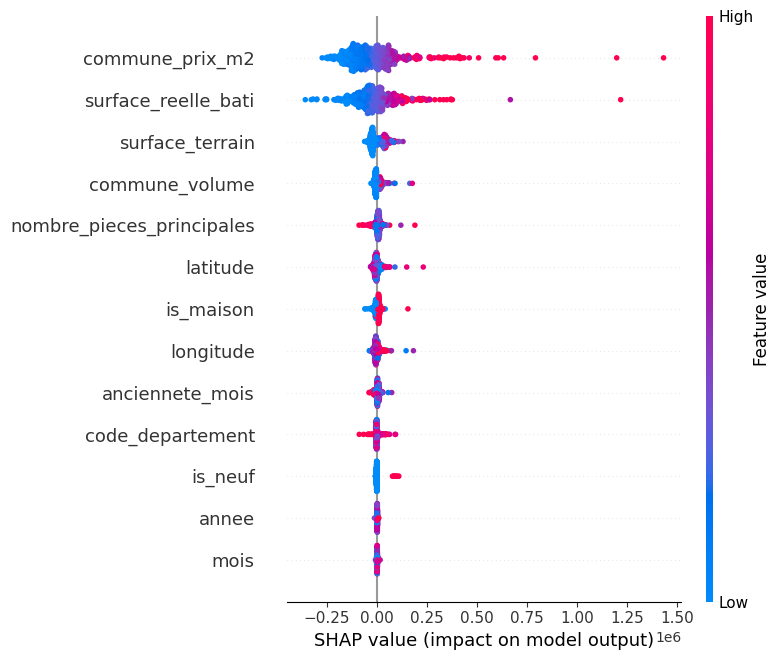

In [26]:
import shap

X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values.values, X_sample)

# 7. Optimisation du modèle champion XBoost
Gridsearch et earlystopping

In [27]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
import numpy as np

# 1. Création d'un sous-ensemble de validation pour l'Early Stopping 
# (Obligatoire pour que XGBoost puisse surveiller l'erreur au fil des itérations)
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

# 2. Définition de la grille d'hyperparamètres pour le GridSearchCV
# Note : On garde la grille volontairement ciblée pour maîtriser le temps de calcul
param_grid = {
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# 3. Initialisation du modèle XGBoost Regressor de base
# On fixe un grand nombre d'arbres (1000) car l'early stopping se chargera de couper
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, 
    tree_method='hist', # Technique 'hist' indispensable pour accélérer sur 3.7M de lignes
    random_state=42,
    n_jobs=-1
)

# 4. Configuration du GridSearchCV (ex: 3-Fold Validation)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=2,
    n_jobs=1 # Laisser XGBoost gérer le parallélisme en interne via n_jobs=-1
)

print("Début de l'optimisation des hyperparamètres...")
# On passe l'échantillon de validation dans les fit_params du GridSearch pour l'early stopping
grid_search.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 5. Extraction du modèle champion optimisé
best_params = grid_search.best_params_
champion_model = grid_search.best_estimator_

print("\n========================================= ")
print(f"Meilleurs hyperparamètres trouvés : {best_params}")
print("========================================= \n")

# 6. Évaluation finale sur l'ensemble de Test original
y_pred = champion_model.predict(X_test)


Début de l'optimisation des hyperparamètres...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, subsample=0.8; total time= 3.7min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, subsample=0.8; total time= 3.6min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, subsample=0.8; total time= 3.3min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, subsample=0.8; total time= 4.1min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, subsample=0.8; total time= 4.0min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, subsample=0.8; total time= 4.0min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, subsample=0.8; total time= 3.4min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, subsample=0.8; total time= 3.3min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, subsample=0.8; total time= 4.2min
[CV] END colsa

In [29]:
import time
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd

# =========================================
# PREDICTION
# =========================================

start_pred = time.time()
y_pred = champion_model.predict(X_test)
pred_time = time.time() - start_pred

# =========================================
# METRIQUES
# =========================================

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Temps total approximatif du GridSearch
train_time = grid_search.cv_results_['mean_fit_time'].sum()

# =========================================
# AFFICHAGE
# =========================================

print("\n" + "=" * 70)
print("RESULTATS MODELE XGBOOST OPTIMISE")
print("=" * 70)

print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f} euros")
print(f"RMSE : {rmse:,.2f} euros")
print(f"MAPE : {mape:.2f} %")

print(f"\nTemps entraînement : {train_time / 60:.2f} minutes")
print(f"Temps prediction   : {pred_time:.2f} secondes")

# =========================================
# SAUVEGARDE CSV
# =========================================

MODEL_NAME = "XGBoost_Optimized_GridSearch"

df_result = pd.DataFrame([{
    "model": MODEL_NAME,
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "train_time_sec": train_time,
    "pred_time_sec": pred_time
}])

df_result.to_csv("result_xgboost_optimized.csv", index=False)

print("\nMétriques sauvegardées avec succès")
print("Fichier : result_xgboost_optimized.csv")


RESULTATS MODELE XGBOOST OPTIMISE
R2   : 0.7466
MAE  : 60,598.16 euros
RMSE : 125,863.59 euros
MAPE : 34.13 %

Temps entraînement : 15.50 minutes
Temps prediction   : 12.27 secondes

Métriques sauvegardées avec succès
Fichier : result_xgboost_optimized.csv
